## 1. Loading the dataset and preparing the environment

In this first step, we import the main Python libraries used throughout the notebook.
`pandas` and `numpy` support data manipulation and numerical operations, `matplotlib`
provides basic visualization, and `scipy.stats` will be used for hypothesis testing.

We load the dataset directly from the local filesystem using `pd.read_csv()` and
inspect the first rows with `.head()`.

In [57]:
# Basic libraries for data manipulation and exploratory analysis
import pandas as pd
import numpy as np

# Basic visualization libraries
import matplotlib.pyplot as plt

# Statistical functions, useful later for hypothesis testing
from scipy import stats

# Plotly renderer for local Jupyter notebooks (works without nbformat)
import plotly.io as pio
pio.renderers.default = "iframe"

In [58]:
# Load the full 2026 dataset and filter to Australian GP Race session
df_all = pd.read_csv("/Users/ftomelin/Documents/Repos/DataScienceFurb/data/raw/All Laps Update 13032026.csv")
df = df_all[
    (df_all["session_type"] == "R") &
    (df_all["event_name"]   == "Australian Grand Prix")
].copy().reset_index(drop=True)
print(f"Race laps: {len(df)} | Drivers: {df['driver'].nunique()} | Compounds: {sorted(df['compound'].dropna().unique())}")
df.head()

Race laps: 1007 | Drivers: 21 | Compounds: ['HARD', 'MEDIUM', 'SOFT']


,season,event_name,circuit,session_type,driver,driver_number,lap_number,lap_time,lap_duration,compound,tyre_age,stint_number,telemetry
0,2026,Australian Grand Prix,Melbourne,R,NOR,1,1,0:00.000,NaN,MEDIUM,1,1,"[{""t"":0,""speed"":0,""throttle"":24,""brake"":1,""gea..."
1,2026,Australian Grand Prix,Melbourne,R,NOR,1,2,1:27.344,87.344,MEDIUM,2,1,"[{""t"":0,""speed"":295,""throttle"":64,""brake"":0,""g..."
2,2026,Australian Grand Prix,Melbourne,R,NOR,1,3,1:26.863,86.863,MEDIUM,3,1,"[{""t"":0,""speed"":306,""throttle"":100,""brake"":0,""..."
3,2026,Australian Grand Prix,Melbourne,R,NOR,1,4,1:25.857,85.857,MEDIUM,4,1,"[{""t"":0,""speed"":288,""throttle"":100,""brake"":0,""..."
4,2026,Australian Grand Prix,Melbourne,R,NOR,1,5,1:25.573,85.573,MEDIUM,5,1,"[{""t"":0,""speed"":285,""throttle"":100,""brake"":0,""..."


## 2. Inspecting the structure of the dataset

After loading the dataset we perform a first structural inspection.
`.shape` shows the number of rows and columns.
`.info()` provides column names, data types, and non-null counts — useful for
identifying missing data and checking import correctness.
`.columns` lists all feature names before we start selecting variables.

In [59]:
# Check dataset dimensions
df.shape

(1007, 13)

In [60]:
# Inspect column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   season         1007 non-null   int64  
 1   event_name     1007 non-null   str    
 2   circuit        1007 non-null   str    
 3   session_type   1007 non-null   str    
 4   driver         1007 non-null   str    
 5   driver_number  1007 non-null   int64  
 6   lap_number     1007 non-null   int64  
 7   lap_time       1007 non-null   str    
 8   lap_duration   980 non-null    float64
 9   compound       1007 non-null   str    
 10  tyre_age       1007 non-null   int64  
 11  stint_number   1007 non-null   int64  
 12  telemetry      1007 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 102.4 KB


In [61]:
# Display all column names
df.columns

Index(['season', 'event_name', 'circuit', 'session_type', 'driver',
       'driver_number', 'lap_number', 'lap_time', 'lap_duration', 'compound',
       'tyre_age', 'stint_number', 'telemetry'],
      dtype='str')

## 3. Frequency tables for categorical variables

We identify non-numeric variables and generate frequency tables for each of them.
These represent categorical information such as driver codes and tyre compounds.

First we use `value_counts()` to obtain absolute frequency of each category.
Then we build a more complete table including absolute frequency, relative frequency,
and percentage. This helps understand how observations are distributed across
categories and detect possible inconsistencies.

In [62]:
# Select non-numeric columns, excluding 'id'
non_numeric_cols = df.select_dtypes(exclude=["number"]).columns.drop("id", errors="ignore")

# Count values for each non-numeric column
for col in non_numeric_cols:
    print(f"\nVariable: {col}")
    print(df[col].value_counts(dropna=False))


Variable: event_name
event_name
Australian Grand Prix    1007
Name: count, dtype: int64

Variable: circuit
circuit
Melbourne    1007
Name: count, dtype: int64

Variable: session_type
session_type
R    1007
Name: count, dtype: int64

Variable: driver
driver
NOR    58
ANT    58
LEC    58
VER    58
HAM    58
RUS    58
GAS    57
ALB    57
LAW    57
OCO    57
LIN    57
BOR    57
BEA    57
COL    56
SAI    56
PER    55
STR    43
ALO    22
BOT    16
HAD    11
HUL     1
Name: count, dtype: int64

Variable: lap_time
lap_time
0:00.000    27
1:23.912     4
1:24.233     2
1:24.790     2
1:23.416     2
            ..
1:24.264     1
1:24.615     1
1:24.610     1
1:26.439     1
1:26.649     1
Name: count, Length: 922, dtype: int64

Variable: compound
compound
HARD      590
MEDIUM    286
SOFT      131
Name: count, dtype: int64

Variable: telemetry
telemetry
[{"t":0,"speed":0,"throttle":24,"brake":1,"gear":1,"rpm":12500,"drs":0,"x":-768,"y":-1740,"z":88},{"t":0.5,"speed":3,"throttle":25,"brake":1,"gea

In [63]:
# Count absolute and relative frequencies for each non-numeric column
for col in non_numeric_cols:
    freq_table = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="absolute_frequency")
    )

    freq_table["relative_frequency"] = (
        freq_table["absolute_frequency"] / len(df)
    ).round(4)

    freq_table["percentage"] = (
        freq_table["relative_frequency"] * 100
    ).round(2)

    print(f"\nVariable: {col}")
    display(freq_table)


Variable: event_name


,event_name,absolute_frequency,relative_frequency,percentage
0,Australian Grand Prix,1007,1.0,100.0



Variable: circuit


,circuit,absolute_frequency,relative_frequency,percentage
0,Melbourne,1007,1.0,100.0



Variable: session_type


...

,lap_time,absolute_frequency,relative_frequency,percentage
0,0:00.000,27,0.0268,2.68
1,1:23.912,4,0.0040,0.40
2,1:24.233,2,0.0020,0.20
3,1:24.790,2,0.0020,0.20
4,1:23.416,2,0.0020,0.20
...,...,...,...,...
917,1:24.264,1,0.0010,0.10
918,1:24.615,1,0.0010,0.10
919,1:24.610,1,0.0010,0.10
920,1:26.439,1,0.0010,0.10



Variable: compound


,compound,absolute_frequency,relative_frequency,percentage
0,HARD,590,0.5859,58.59
1,MEDIUM,286,0.2840,28.40
2,SOFT,131,0.1301,13.01



Variable: telemetry


,telemetry,absolute_frequency,relative_frequency,percentage
0,"[{""t"":0,""speed"":0,""throttle"":24,""brake"":1,""gea...",1,0.001,0.1
1,"[{""t"":0,""speed"":295,""throttle"":64,""brake"":0,""g...",1,0.001,0.1
2,"[{""t"":0,""speed"":306,""throttle"":100,""brake"":0,""...",1,0.001,0.1
3,"[{""t"":0,""speed"":288,""throttle"":100,""brake"":0,""...",1,0.001,0.1
4,"[{""t"":0,""speed"":285,""throttle"":100,""brake"":0,""...",1,0.001,0.1
...,...,...,...,...
1002,"[{""t"":0,""speed"":297,""throttle"":100,""brake"":0,""...",1,0.001,0.1
1003,"[{""t"":0,""speed"":297,""throttle"":100,""brake"":0,""...",1,0.001,0.1
1004,"[{""t"":0,""speed"":300,""throttle"":100,""brake"":0,""...",1,0.001,0.1
1005,"[{""t"":0,""speed"":301,""throttle"":100,""brake"":0,""...",1,0.001,0.1


## 4. Simple bar charts for categorical variables

After producing frequency tables we represent categorical distributions visually
using bar charts. Each bar represents one category and its height corresponds to
the number of laps in that category. These plots give a quick visual summary of
the categorical composition of the dataset.

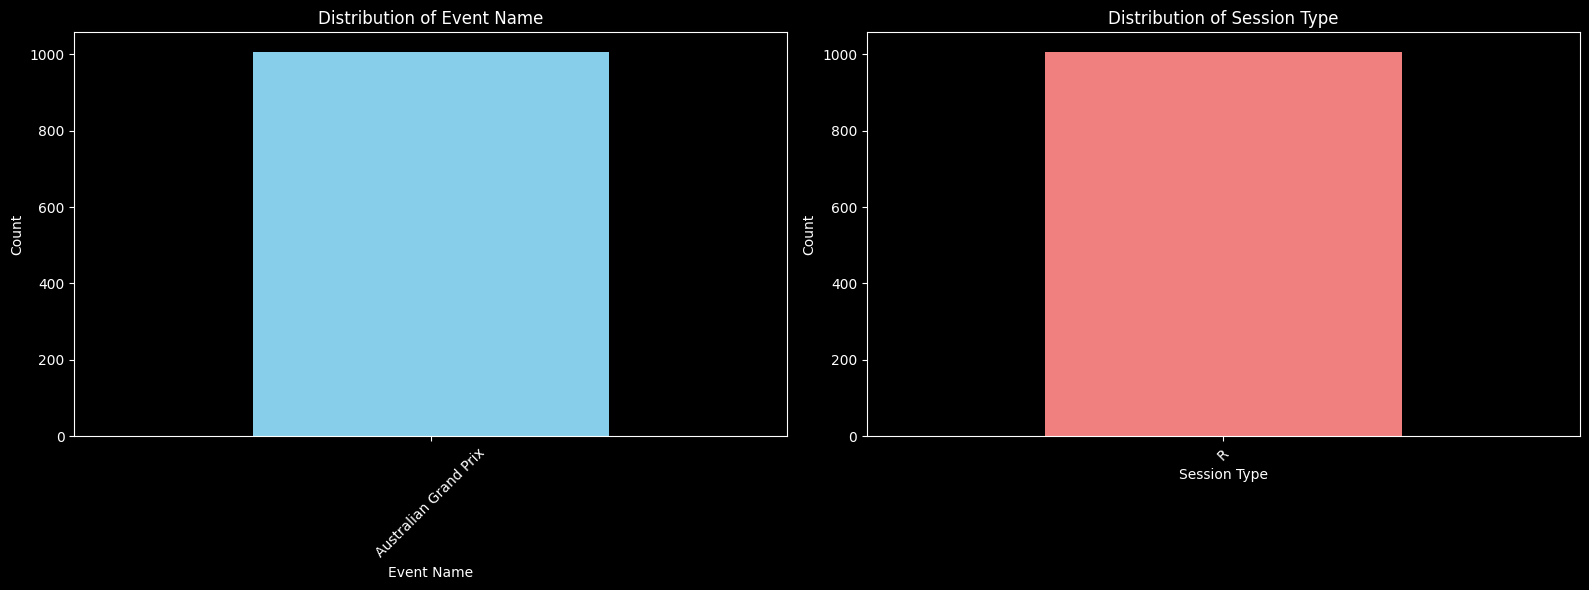

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for 'event_name'
df['event_name'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Event Name')
axes[0].set_xlabel('Event Name')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart for 'session_type'
df['session_type'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Session Type')
axes[1].set_xlabel('Session Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

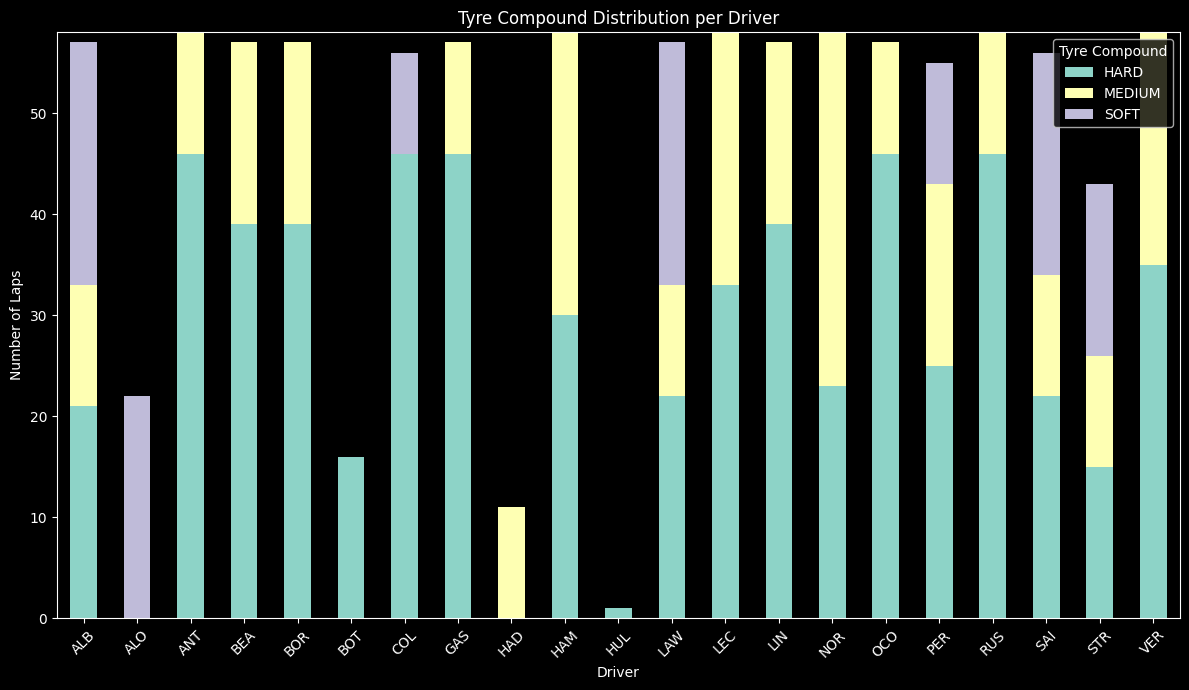

In [65]:
plt.figure(figsize=(12, 7))
df.groupby(['driver', 'compound']).size().unstack(fill_value=0).plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Tyre Compound Distribution per Driver')
plt.xlabel('Driver')
plt.ylabel('Number of Laps')
plt.xticks(rotation=45)
plt.legend(title='Tyre Compound')
plt.tight_layout()
plt.show()

## 5. Cumulative frequency for an ordinal variable

Here we calculate a cumulative frequency table for `tyre_age`.
Unlike purely nominal variables, `tyre_age` has a meaningful order (tyres wear
progressively). Cumulative frequencies answer questions such as:
"What proportion of laps were completed with tyres aged up to X laps?" 


Cumulative Frequency Table for 'tyre_age':


,absolute_frequency,relative_frequency,cumulative_absolute_frequency,cumulative_percentage
tyre_age,,,,
1,50,0.049652,50,4.965243
2,49,0.048659,99,9.831182
3,49,0.048659,148,14.697120
4,49,0.048659,197,19.563059
5,48,0.047666,245,24.329692
6,47,0.046673,292,28.997021
7,47,0.046673,339,33.664350
8,47,0.046673,386,38.331678
9,46,0.045680,432,42.899702


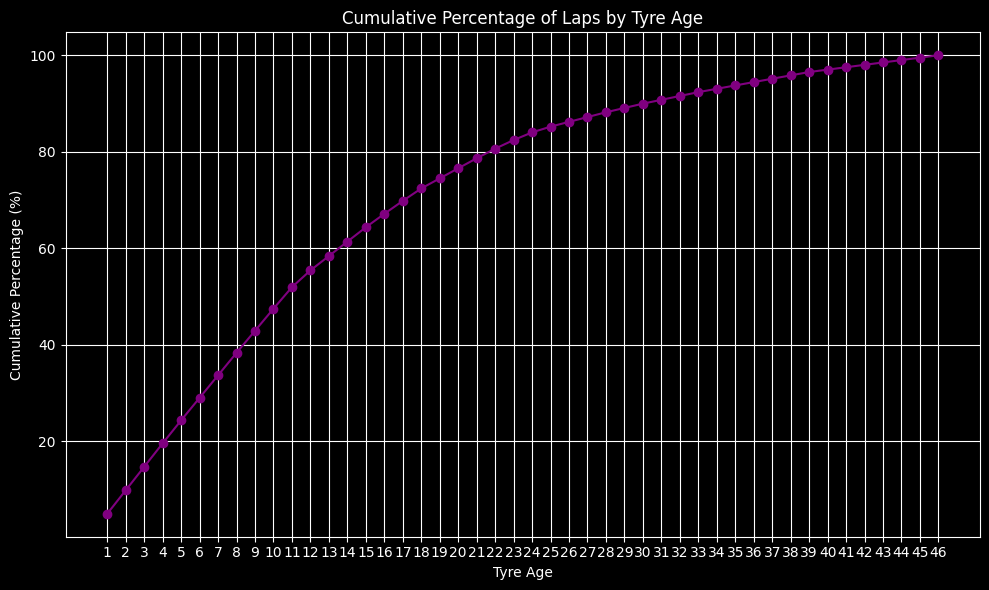

In [66]:
# Calculate absolute frequencies
freq_tyre_age = df['tyre_age'].value_counts().sort_index()

# Convert to DataFrame for easier manipulation
freq_df = pd.DataFrame({
    'absolute_frequency': freq_tyre_age,
    'relative_frequency': freq_tyre_age / len(df)
})

# Calculate cumulative absolute frequency
freq_df['cumulative_absolute_frequency'] = freq_df['absolute_frequency'].cumsum()

# Calculate cumulative relative frequency (percentage)
freq_df['cumulative_percentage'] = freq_df['relative_frequency'].cumsum() * 100

# Display the cumulative frequency table
print("\nCumulative Frequency Table for 'tyre_age':")
display(freq_df)

# Plotting the cumulative frequency
plt.figure(figsize=(10, 6))
freq_df['cumulative_percentage'].plot(kind='line', marker='o', color='purple')
plt.title('Cumulative Percentage of Laps by Tyre Age')
plt.xlabel('Tyre Age')
plt.ylabel('Cumulative Percentage (%)')
plt.grid(True)
plt.xticks(freq_df.index)
plt.tight_layout()
plt.show()

## 6. Small multiples for categorical variables

Using Plotly we create a refined visualization of categorical variables organized
into subplots. For each variable the code calculates the absolute frequency and
its percentage. The percentages appear directly on the bars while hover information
shows both count and percentage.

In [67]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Categorical variables to visualize from the current dataset
categorical_vars = [
    "driver",
    "compound"
]

# Create a 1x2 subplot layout
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Driver",
        "Tyre Compound"
    ]
)

# Position of each subplot
positions = [
    (1, 1),
    (1, 2)
]

# Add one bar chart per categorical variable
for var, position in zip(categorical_vars, positions):
    counts = df[var].value_counts(dropna=False)
    percentages = (counts / len(df) * 100).round(1)

    row, col = position

    fig.add_trace(
        go.Bar(
            x=counts.index.astype(str),
            y=counts.values,
            text=percentages.astype(str) + "%",
            textposition="auto",
            name=var,
            hovertemplate=(
                "<b>%{x}</b><br>" + "Contagem de Voltas: %{y}<br>" + "Porcentagem: %{text}<extra></extra>" # Updated hovertemplate
            )
        ),
        row=row,
        col=col
    )

# Layout adjustments
fig.update_layout(
    title_text="Distribution of Selected Categorical Variables (Free Trainning)",
    height=500,
    width=800,
    showlegend=True # Changed to True to display legend
)

# Improve axis readability
fig.update_xaxes(tickangle=30)

fig.show()

## 7. Descriptive statistics for numerical variables

We compute basic descriptive statistics for the numerical variables in the dataset.
The `.describe()` method summarizes each variable using count, mean, standard
deviation, minimum, quartiles, median, and maximum. We transpose the output with
`.T` to place variables in rows and statistics in columns, and round to two decimal
places for readability.

In [68]:
# Basic descriptive statistics for numeric variables, excluding 'id'

numeric_cols = df.select_dtypes(include=["number"]).columns.drop("id", errors="ignore")

df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
season,1007.0,2026.00,0.00,2026.00,2026.00,2026.00,2026.00,2026.00
driver_number,1007.0,29.30,23.73,1.00,11.00,23.00,43.00,87.00
lap_number,1007.0,27.78,16.61,1.00,13.00,27.00,42.00,58.00
lap_duration,980.0,87.85,8.25,82.09,83.98,85.19,87.09,132.25
tyre_age,1007.0,13.99,10.77,1.00,6.00,11.00,20.00,46.00
stint_number,1007.0,1.92,0.74,1.00,1.00,2.00,2.00,5.00


In [69]:
# Transposed version for easier reading

df[numeric_cols].describe().T

# df_pivot = df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
season,1007.0,2026.000000,0.000000,2026.000,2026.00000,2026.000,2026.00000,2026.000
driver_number,1007.0,29.295929,23.729083,1.000,11.00000,23.000,43.00000,87.000
lap_number,1007.0,27.776564,16.606627,1.000,13.00000,27.000,42.00000,58.000
lap_duration,980.0,87.853956,8.254375,82.091,83.97675,85.188,87.09325,132.251
tyre_age,1007.0,13.989076,10.773231,1.000,6.00000,11.000,20.00000,46.000
stint_number,1007.0,1.919563,0.737038,1.000,1.00000,2.000,2.00000,5.000


In [70]:
# Descriptive statistics with rounded values

df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
season,1007.0,2026.00,0.00,2026.00,2026.00,2026.00,2026.00,2026.00
driver_number,1007.0,29.30,23.73,1.00,11.00,23.00,43.00,87.00
lap_number,1007.0,27.78,16.61,1.00,13.00,27.00,42.00,58.00
lap_duration,980.0,87.85,8.25,82.09,83.98,85.19,87.09,132.25
tyre_age,1007.0,13.99,10.77,1.00,6.00,11.00,20.00,46.00
stint_number,1007.0,1.92,0.74,1.00,1.00,2.00,2.00,5.00


## 8. Examining the distribution of a numerical variable

In this section we analyze the distribution of `lap_duration` — the lap time in
seconds for each valid lap. We begin with a histogram to assess the overall shape,
center, and spread of the distribution. Then we add a box plot to summarize the
distribution through the median, quartiles, interquartile range, and potential
outliers. Both visualizations are combined in a single figure using
`make_subplots()`.

In [71]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Choose 'lap_duration' as the numerical variable for analysis
numerical_variable = "lap_duration"

# Create subplots for histogram and box plot
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Histogram of Lap Duration", "Box Plot of Lap Duration"]
)

# Add Histogram
fig.add_trace(
    go.Histogram(
        x=df[numerical_variable].dropna(),
        name='Histogram',
        marker_color='#636EFA'
    ),
    row=1,
    col=1
)

# Add Box Plot
fig.add_trace(
    go.Box(
        y=df[numerical_variable].dropna(),
        name='Box Plot',
        marker_color='#EF553B'
    ),
    row=1,
    col=2
)

# Update layout and titles
fig.update_layout(
    title_text=f"Distribution Analysis of {numerical_variable.replace('_', ' ').title()}",
    height=500,
    showlegend=False
)

fig.update_xaxes(title_text="Lap Duration (seconds)", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=1)
fig.update_yaxes(title_text="Lap Duration (seconds)", row=1, col=2)

fig.show()

## 9. Comparing symmetric and skewed distributions

We now examine how measures of central tendency behave in two different types of
distributions.

First we analyze `lap_duration` (valid laps only). The mean and median are expected
to be relatively similar if the distribution is roughly symmetric.

Then we analyze `tyre_age` for all laps. Tyre age tends to be right-skewed because
more laps are recorded at low tyre ages (early stints) while some stints go well
beyond the median, pulling the mean above the median.

The histograms include vertical reference lines for the mean and the median.
If the lines are close to each other the distribution is not strongly skewed.

In [72]:
# Basic descriptive statistics for lap_duration
df["lap_duration"].describe().round(2)

count    980.00
mean      87.85
std        8.25
min       82.09
25%       83.98
50%       85.19
75%       87.09
max      132.25
Name: lap_duration, dtype: float64

In [73]:
# Mean and median comparison for lap_duration
mean_lap = df["lap_duration"].mean()
median_lap = df["lap_duration"].median()
std_lap = df["lap_duration"].std()

print(f"Mean:               {mean_lap:.2f} s")
print(f"Median:             {median_lap:.2f} s")
print(f"Standard deviation: {std_lap:.2f} s")

Mean:               87.85 s
Median:             85.19 s
Standard deviation: 8.25 s


In [74]:
import plotly.express as px

var = "lap_duration"
mean_val = df[var].mean()
median_val = df[var].median()

fig = px.histogram(
    df.dropna(subset=[var]),
    x=var,
    nbins=30,
    title="Distribution of Lap Duration with Mean and Median",
    labels={var: "Lap duration (seconds)", "count": "Number of laps"}
)
fig.add_vline(
    x=mean_val, line_dash="dash",
    annotation_text=f"Mean: {mean_val:.2f}",
    annotation_position="top left"
)
fig.add_vline(
    x=median_val, line_dash="dot",
    annotation_text=f"Median: {median_val:.2f}",
    annotation_position="top right"
)
fig.update_layout(xaxis_title="Lap duration (seconds)", yaxis_title="Number of laps", bargap=0.05)
fig.show()

In [75]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

var = "tyre_age"
mean_val = df[var].mean()
median_val = df[var].median()

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.75, 0.25],
    vertical_spacing=0.08,
    subplot_titles=["Histogram of Tyre Age", "Box Plot of Tyre Age"]
)

fig.add_trace(
    go.Histogram(x=df[var], nbinsx=22, name="Histogram",
                 hovertemplate="Age: %{x}<br>Count: %{y}<extra></extra>"),
    row=1, col=1
)
fig.add_trace(
    go.Box(x=df[var], name="Box plot", boxpoints="outliers",
           hovertemplate="Age: %{x}<extra></extra>"),
    row=2, col=1
)
fig.add_vline(x=mean_val, line_dash="dash",
              annotation_text=f"Mean: {mean_val:.2f}", annotation_position="top left")
fig.add_vline(x=median_val, line_dash="dot",
              annotation_text=f"Median: {median_val:.2f}", annotation_position="top right")

fig.update_layout(
    title_text="Distribution Analysis: Tyre Age",
    height=650, width=950, showlegend=False
)
fig.update_xaxes(title_text="Tyre age (laps)", row=2, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.show()

## 10. Skewness and kurtosis

We now compare two distributions using skewness and kurtosis.

`lap_duration` represents a more symmetric distribution among the valid lap times.
Its mean and median are expected to be relatively close and its skewness near zero.

`tyre_age` shows a different pattern. Because most laps occur at lower tyre ages
(fresh tyres at the start of stints) while some stints can run quite long, the
distribution is positively skewed.

In pandas, `.kurt()` returns excess kurtosis where values close to zero resemble a
normal distribution. A high positive value indicates heavy tails and extreme values.

In [76]:
# Series for each variable
lap_data = df["lap_duration"].dropna()
tyre_data = df["tyre_age"].dropna()

In [77]:
# Compare skewness and kurtosis
distribution_comparison = pd.DataFrame({
    "variable": [
        "lap_duration (valid laps only)",
        "tyre_age"
    ],
    "mean":               [lap_data.mean(),   tyre_data.mean()],
    "median":             [lap_data.median(), tyre_data.median()],
    "standard_deviation": [lap_data.std(),    tyre_data.std()],
    "skewness":           [lap_data.skew(),   tyre_data.skew()],
    "kurtosis":           [lap_data.kurt(),   tyre_data.kurt()]
})
distribution_comparison.round(2)

,variable,mean,median,standard_deviation,skewness,kurtosis
0,lap_duration (valid laps only),87.85,85.19,8.25,2.87,7.82
1,tyre_age,13.99,11.00,10.77,1.03,0.42


## 11. Analytical comment on the output

The results show a contrast between the two distributions.

`lap_duration` among valid laps displays mean and median values that are relatively
close to each other. Its skewness is moderate and kurtosis is near zero, indicating
an approximately symmetric distribution without particularly heavy tails.

`tyre_age` follows a different pattern. Because more laps are logged at lower tyre
ages (start of each stint), while a smaller number of laps run on very old tyres,
the distribution is positively skewed. The mean is pulled above the median by the
longer stints, and the kurtosis may be elevated due to the concentration of laps
at low ages combined with a long right tail.

This comparison illustrates why descriptive statistics must be interpreted in
relation to distribution shape. For `lap_duration`, the mean and standard deviation
are relatively informative. For `tyre_age`, the median and interquartile range are
more robust summaries.

## 12. Comparing dispersion in symmetric and asymmetric distributions

In this section we compare dispersion measures for `lap_duration` and `tyre_age`.

The function `dispersion_summary()` computes count, min, max, range, mean, median,
variance, standard deviation, quartiles, interquartile range, and coefficient of
variation. The resulting table highlights how dispersion behaves differently
depending on distribution shape.

The side-by-side box plots complement the table. For `lap_duration` the box plot
is expected to look more balanced, while for `tyre_age` a longer upper tail with
more outliers is typical.

In [78]:
symmetric_var   = "lap_duration"
asymmetric_var  = "tyre_age"

symmetric_data  = df[symmetric_var].dropna()
asymmetric_data = df[asymmetric_var].dropna()

def dispersion_summary(series):
    return pd.Series({
        "count":                   series.count(),
        "min":                     series.min(),
        "max":                     series.max(),
        "range":                   series.max() - series.min(),
        "mean":                    series.mean(),
        "median":                  series.median(),
        "variance":                series.var(),
        "standard_deviation":      series.std(),
        "q1":                      series.quantile(0.25),
        "q3":                      series.quantile(0.75),
        "iqr":                     series.quantile(0.75) - series.quantile(0.25),
        "coefficient_of_variation": series.std() / series.mean()
    })

In [79]:
dispersion_comparison = pd.DataFrame({
    "lap_duration": dispersion_summary(symmetric_data),
    "tyre_age":     dispersion_summary(asymmetric_data)
})
dispersion_comparison.T.round(2)

,count,min,max,range,mean,median,variance,standard_deviation,q1,q3,iqr,coefficient_of_variation
lap_duration,980.0,82.09,132.25,50.16,87.85,85.19,68.13,8.25,83.98,87.09,3.12,0.09
tyre_age,1007.0,1.00,46.00,45.00,13.99,11.00,116.06,10.77,6.00,20.00,14.00,0.77


In [80]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Lap Duration (seconds)",
        "Tyre Age (laps)"
    ]
)

fig.add_trace(
    go.Box(y=symmetric_data, name="Lap duration", boxpoints="outliers", boxmean=True,
           hovertemplate="Value: %{y:.2f}<extra></extra>"),
    row=1, col=1
)
fig.add_trace(
    go.Box(y=asymmetric_data, name="Tyre age", boxpoints="outliers", boxmean=True,
           hovertemplate="Value: %{y}<extra></extra>"),
    row=1, col=2
)

fig.update_layout(
    title="Dispersion Comparison: Lap Duration vs. Tyre Age",
    height=550, width=1000, showlegend=False
)
fig.update_yaxes(title_text="Lap duration (s)", row=1, col=1)
fig.update_yaxes(title_text="Tyre age (laps)", row=1, col=2)
fig.show()

## 13. Visualizing dispersion with histograms and standard deviation lines

This section compares `lap_duration` and `tyre_age` using histograms with three
vertical reference lines each: the mean, one standard deviation below, and one
standard deviation above.

For `lap_duration` the interval defined by mean ± 1 SD is expected to align
reasonably with the central concentration of the data.

For `tyre_age` the same visual reference can be harder to interpret: the mean is
pulled right by longer stints and the standard deviation becomes larger, so the
lower bound of mean − 1 SD may approach zero (or even become negative in practice
for other skewed variables), indicating that the standard deviation is heavily
influenced by the right tail.

In [81]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

sym_data  = df["lap_duration"].dropna()
asym_data = df["tyre_age"].dropna()

sym_mean  = sym_data.mean();   sym_std  = sym_data.std()
asym_mean = asym_data.mean();  asym_std = asym_data.std()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Lap Duration (seconds)",
        "Tyre Age (laps)"
    ]
)

fig.add_trace(
    go.Histogram(x=sym_data, nbinsx=30, name="Lap duration",
                 hovertemplate="Value: %{x:.2f}<br>Count: %{y}<extra></extra>"),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=asym_data, nbinsx=22, name="Tyre age",
                 hovertemplate="Age: %{x}<br>Count: %{y}<extra></extra>"),
    row=1, col=2
)

# Lines for lap_duration
for x, dash, label, pos in [
    (sym_mean,            "solid", f"Mean = {sym_mean:.2f}",           "top right"),
    (sym_mean - sym_std,  "dash",  f"-1 SD = {sym_mean - sym_std:.2f}","top left"),
    (sym_mean + sym_std,  "dash",  f"+1 SD = {sym_mean + sym_std:.2f}","top right"),
]:
    fig.add_vline(x=x, line_dash=dash, annotation_text=label,
                  annotation_position=pos, row=1, col=1)

# Lines for tyre_age
for x, dash, label, pos in [
    (asym_mean,             "solid", f"Mean = {asym_mean:.2f}",              "top right"),
    (asym_mean - asym_std,  "dash",  f"-1 SD = {asym_mean - asym_std:.2f}", "top left"),
    (asym_mean + asym_std,  "dash",  f"+1 SD = {asym_mean + asym_std:.2f}", "top right"),
]:
    fig.add_vline(x=x, line_dash=dash, annotation_text=label,
                  annotation_position=pos, row=1, col=2)

fig.update_layout(
    title="Dispersion in Two Distributions: Mean and Standard Deviation",
    height=500, width=1100, showlegend=False, bargap=0.05
)
fig.update_xaxes(title_text="Lap duration (seconds)", row=1, col=1)
fig.update_xaxes(title_text="Tyre age (laps)", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=2)
fig.show()

## 14. Interpreting the histograms with mean and standard deviation

The two histograms show how the same descriptive measure — the standard deviation —
behaves differently depending on the shape of the distribution.

For `lap_duration`, the distribution of valid racing laps is approximately
symmetric. The interval mean ± 1 SD captures the central bulk of the data
reasonably well, and the standard deviation provides a useful summary of
variability around the mean.

For `tyre_age`, the distribution is positively skewed: many laps occur at low tyre
ages (fresh tyres at the start of each stint) while a smaller number of laps are
completed on very old tyres. The mean is pulled above the median by the long right
tail, and the standard deviation is correspondingly larger. This comparison
highlights that the standard deviation is most directly interpretable in
approximately symmetric distributions; in skewed distributions the median and
interquartile range are often more robust summaries.

## 15. Scatter plots for relationships between numerical variables

In this section we begin to analyze relationships between two numerical variables
using scatter plots.

The first plot compares `tyre_age` and `lap_duration` among valid laps. This allows
us to inspect whether older tyres are associated with slower lap times — a key
aspect of tyre degradation analysis in Formula 1.

The second plot compares `lap_number` and `lap_duration`. As the session progresses
drivers often improve their lap times through track evolution and setup changes.

In both cases the scatter plot provides a first visual indication of association,
dispersion, outliers, and possible trends.

In [82]:
import plotly.express as px

df_scatter = df.dropna(subset=["lap_duration"]).copy()

fig = px.scatter(
    df_scatter,
    x="tyre_age",
    y="lap_duration",
    opacity=0.6,
    title="Tyre Age vs Lap Duration",
    labels={
        "tyre_age":     "Tyre age (laps)",
        "lap_duration": "Lap duration (seconds)"
    }
)
fig.update_layout(xaxis_title="Tyre age (laps)", yaxis_title="Lap duration (seconds)")
fig.show()

In [83]:
df_scatter = df.dropna(subset=["lap_duration"]).copy()

fig = px.scatter(
    df_scatter,
    x="lap_number",
    y="lap_duration",
    opacity=0.6,
    title="Lap Number vs Lap Duration",
    labels={
        "lap_number":   "Lap number",
        "lap_duration": "Lap duration (seconds)"
    }
)
fig.update_layout(xaxis_title="Lap number", yaxis_title="Lap duration (seconds)")
fig.show()

## 16. Correlation between tyre age and lap duration

This section examines the relationship between `tyre_age` and `lap_duration`.

We calculate two correlation coefficients. Pearson's correlation measures the
strength and direction of a linear association. Spearman's correlation measures
whether the relationship is monotonic using ranked values.

The scatter plot with an OLS trend line summarises the direction of the association.
The annotation box reports both coefficients and their p-values directly on the
plot.

A positive correlation would indicate that laps on older tyres tend to be slower —
consistent with tyre degradation. Both the p-values and the visual spread of points
help assess how strong and consistent this association is.

In [84]:
from scipy import stats
import plotly.express as px

x_var = "tyre_age"
y_var = "lap_duration"

df_corr = df[[x_var, y_var]].dropna()

pearson_r,   pearson_p   = stats.pearsonr(df_corr[x_var], df_corr[y_var])
spearman_rho, spearman_p = stats.spearmanr(df_corr[x_var], df_corr[y_var])

print(f"Pearson correlation:  r = {pearson_r:.3f},   p-value = {pearson_p:.4f}")
print(f"Spearman correlation: ρ = {spearman_rho:.3f}, p-value = {spearman_p:.4f}")

Pearson correlation:  r = -0.170,   p-value = 0.0000
Spearman correlation: ρ = -0.287, p-value = 0.0000


In [85]:
fig = px.scatter(
    df_corr,
    x=x_var,
    y=y_var,
    opacity=0.6,
    trendline="ols",
    title="Tyre Age vs Lap Duration",
    labels={
        x_var: "Tyre age (laps)",
        y_var: "Lap duration (seconds)"
    }
)
fig.add_annotation(
    x=0.02, y=0.98,
    xref="paper", yref="paper",
    showarrow=False, align="left",
    text=(
        f"<b>Correlation coefficients</b><br>"
        f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.4f})<br>"
        f"Spearman ρ = {spearman_rho:.3f} (p = {spearman_p:.4f})"
    ),
    bgcolor="white", bordercolor="black", borderwidth=1, font=dict(size=12)
)
fig.update_layout(
    xaxis_title="Tyre age (laps)",
    yaxis_title="Lap duration (seconds)",
    width=950, height=550
)
fig.show()

## 17. Correlation heatmap for numerical variables

In this step we examine the correlation structure among numerical variables using a
Pearson correlation matrix.

We exclude `season` (constant throughout the dataset) and `driver_number` (an
identifier with no substantive analytical meaning). The remaining numerical
variables — `lap_number`, `lap_duration`, `tyre_age`, and `stint_number` — are
included.

The heatmap makes it possible to inspect many pairwise relationships at once and
identify broader patterns, such as clusters of positively related variables, weak
associations, and possible inverse relationships.

In [86]:
import plotly.express as px

numeric_vars = (
    df.select_dtypes(include=["number"])
      .columns
      .drop(["season", "driver_number"], errors="ignore")
)

corr_matrix = df[numeric_vars].corr(method="pearson")

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    zmin=-1, zmax=1,
    color_continuous_scale="RdBu_r",
    title="Pearson Correlation Heatmap: Numerical Variables"
)
fig.update_layout(
    width=900, height=750,
    xaxis_title="Variables",
    yaxis_title="Variables"
)
fig.update_xaxes(tickangle=45)
fig.show()

## 18. Correlation heatmap filtering valid laps only

In this step we recalculate the Pearson correlation matrix after filtering the
dataset to include only rows where `lap_duration` is not null — i.e., valid
racing laps, excluding installation laps and laps where no time was recorded.

The goal is to examine how filtering the dataset affects the correlation structure.
Rows with missing `lap_duration` correspond to slow, non-representative laps that
may distort the relationship between `tyre_age`, `lap_number`, and `lap_duration`.

This is analogous to the effect that transforming or filtering a variable can have
on Pearson correlation: removing non-representative observations can make linear
relationships more visible.

In [87]:
import plotly.express as px

df_valid = df.dropna(subset=["lap_duration"]).copy()

numeric_vars_filtered = (
    df_valid.select_dtypes(include=["number"])
            .columns
            .drop(["season", "driver_number"], errors="ignore")
)

corr_matrix_filtered = df_valid[numeric_vars_filtered].corr(method="pearson")

fig = px.imshow(
    corr_matrix_filtered,
    text_auto=".2f",
    zmin=-1, zmax=1,
    color_continuous_scale="RdBu_r",
    title="Pearson Correlation Heatmap: Valid Laps Only"
)
fig.update_layout(
    width=900, height=750,
    xaxis_title="Variables",
    yaxis_title="Variables"
)
fig.update_xaxes(tickangle=45)
fig.show()

## 19. Comparing lap duration by tyre compound

In this section we compare `lap_duration` across the three tyre compounds used in
the session: SOFT, MEDIUM, and HARD.

The first box plot shows the raw lap duration distribution per compound. The second
box plot uses a logarithmic y-axis which can make the distributions easier to
compare visually when the data contain very high or very low outliers.

These complementary views help assess whether different compounds are associated
with systematically faster or slower lap times.

In [88]:
df_compound = df.dropna(subset=["lap_duration"]).copy()
df_compound[["compound", "lap_duration"]].head()

,compound,lap_duration
1,MEDIUM,87.344
2,MEDIUM,86.863
3,MEDIUM,85.857
4,MEDIUM,85.573
5,MEDIUM,85.036


In [89]:
import plotly.express as px

fig = px.box(
    df_compound,
    x="compound",
    y="lap_duration",
    points="outliers",
    title="Lap Duration by Tyre Compound",
    labels={
        "compound":     "Tyre compound",
        "lap_duration": "Lap duration (seconds)"
    }
)
fig.update_layout(
    width=850, height=550,
    xaxis_title="Tyre compound",
    yaxis_title="Lap duration (seconds)"
)
fig.show()

In [90]:
fig = px.box(
    df_compound,
    x="compound",
    y="lap_duration",
    points="outliers",
    title="Lap Duration by Tyre Compound — Log Scale",
    labels={
        "compound":     "Tyre compound",
        "lap_duration": "Lap duration (seconds)"
    },
    log_y=True
)
fig.update_layout(
    width=850, height=550,
    xaxis_title="Tyre compound",
    yaxis_title="Lap duration (seconds, log scale)"
)
fig.show()

## 20. Descriptive comparison of lap duration by tyre compound

Here we calculate descriptive statistics for `lap_duration` by tyre compound,
including count, mean, median, standard deviation, quartiles, and IQR.

Because lap times may be affected by outliers (e.g., slow installation laps at the
beginning of a stint, safety-car laps), we also show an overlaid histogram using
probability density so the shapes of the compound distributions are directly
comparable even when group sizes differ.

In [91]:
compound_summary = (
    df_compound
    .groupby("compound")["lap_duration"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        min="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max="max"
    )
)
compound_summary["iqr"] = compound_summary["q3"] - compound_summary["q1"]
compound_summary.round(2)

,count,mean,median,standard_deviation,min,q1,q3,max,iqr
compound,,,,,,,,,
HARD,584,87.49,84.93,8.01,82.09,83.47,86.73,130.38,3.26
MEDIUM,270,88.89,85.56,9.56,82.36,84.08,87.58,132.25,3.50
SOFT,126,87.32,85.91,5.87,82.93,84.71,87.37,122.34,2.65


In [92]:
import plotly.express as px

fig = px.histogram(
    df_compound,
    x="lap_duration",
    color="compound",
    nbins=30,
    histnorm="probability density",
    barmode="overlay",
    opacity=0.55,
    title="Distribution of Lap Duration by Tyre Compound",
    labels={
        "lap_duration": "Lap duration (seconds)",
        "compound":     "Tyre compound"
    }
)
fig.update_layout(
    width=900, height=550,
    xaxis_title="Lap duration (seconds)",
    yaxis_title="Probability density",
    legend_title="Tyre compound"
)
fig.show()

## 21. Hypothesis testing: lap duration differences by tyre compound

We now move from descriptive comparison to formal hypothesis testing. The analysis
compares lap duration between the **SOFT** and **HARD** compounds — the two extremes
of the tyre spectrum used in the Australian GP race.

Two tests are used because lap times can be skewed by outlier laps (safety car, pit laps).

**Welch's t-test**: parametric, assumes approximate normality. Robust to unequal variances.

**Mann-Whitney U**: non-parametric, compares rank distributions. No normality assumption.

Both share the same hypotheses:
- H0: SOFT and HARD compounds produce the same lap duration distribution
- H1: SOFT and HARD compounds produce different lap duration distributions

In [93]:
from scipy import stats
import numpy as np

df_hyp = df.dropna(subset=["lap_duration"]).copy()
df_hyp = df_hyp[df_hyp["compound"].isin(["SOFT", "HARD"])]

soft_laps = df_hyp[df_hyp["compound"] == "SOFT"]["lap_duration"].dropna()
hard_laps = df_hyp[df_hyp["compound"] == "HARD"]["lap_duration"].dropna()

print(f"SOFT laps: {len(soft_laps)}")
print(f"HARD laps: {len(hard_laps)}")

SOFT laps: 126
HARD laps: 584


In [94]:
# Welch's t-test
# H0: mean lap duration is equal for SOFT and HARD
# H1: mean lap duration differs between SOFT and HARD
t_stat, t_pvalue = stats.ttest_ind(soft_laps, hard_laps, equal_var=False)

print("Welch's t-test on lap duration")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {t_pvalue:.6f}")

Welch's t-test on lap duration
t-statistic: -0.2843
p-value:     0.776429


In [95]:
# Mann-Whitney U test
# H0: the lap duration distributions are similar across SOFT and HARD compounds
# H1: the lap duration distributions differ
u_stat, u_pvalue = stats.mannwhitneyu(soft_laps, hard_laps, alternative="two-sided")

print("Mann-Whitney U test on lap duration")
print(f"U-statistic: {u_stat:.4f}")
print(f"p-value:     {u_pvalue:.6f}")

Mann-Whitney U test on lap duration
U-statistic: 44849.0000
p-value:     0.000114


In [96]:
alpha = 0.05
print(f"Interpretation with alpha = {alpha}")
print()

if t_pvalue < alpha:
    print("Welch's t-test: reject H0.")
    print("There is evidence of a statistically significant difference in mean lap duration between SOFT and HARD compounds.")
else:
    print("Welch's t-test: fail to reject H0.")
    print("There is not enough evidence of a difference in mean lap duration between SOFT and HARD compounds.")

print()

if u_pvalue < alpha:
    print("Mann-Whitney U: reject H0.")
    print("The lap duration distributions differ significantly between SOFT and HARD compounds.")
else:
    print("Mann-Whitney U: fail to reject H0.")
    print("No significant distributional difference in lap duration between SOFT and HARD compounds.")

Interpretation with alpha = 0.05

Welch's t-test: fail to reject H0.
There is not enough evidence of a difference in mean lap duration between SOFT and HARD compounds.

Mann-Whitney U: reject H0.
The lap duration distributions differ significantly between SOFT and HARD compounds.


## 22. Interpreting the hypothesis test results

Both tests evaluate whether SOFT and HARD tyre compounds produce systematically
different lap times during the Australian GP race.

If the p-values are below 0.05 we reject the respective null hypothesis and
conclude that there is statistical evidence of a compound effect on lap duration.

In a race context this difference is expected: SOFT tyres degrade faster but offer
better initial grip, while HARD tyres deliver more consistent lap times over longer stints.
The statistical tests confirm whether this physical difference is significant at the
population level, not just a sampling artefact.

In [97]:
# Difference in raw lap duration means and medians
soft_mean   = soft_laps.mean()
hard_mean   = hard_laps.mean()

soft_median   = soft_laps.median()
hard_median   = hard_laps.median()

print("Lap duration comparison (SOFT vs HARD)")
print(f"SOFT mean:     {soft_mean:.3f} s")
print(f"HARD mean:     {hard_mean:.3f} s")
print(f"Difference:    {abs(soft_mean - hard_mean):.3f} s")
print()
print(f"SOFT median:   {soft_median:.3f} s")
print(f"HARD median:   {hard_median:.3f} s")
print(f"Difference:    {abs(soft_median - hard_median):.3f} s")

Lap duration comparison (SOFT vs HARD)
SOFT mean:     87.317 s
HARD mean:     87.493 s
Difference:    0.176 s

SOFT median:   85.913 s
HARD median:   84.927 s
Difference:    0.986 s


## 23. Effect size: Cohen's d

After testing whether the lap duration difference is statistically significant we
calculate Cohen's d to estimate the size of the difference.

The p-value indicates whether the observed difference is unlikely under the null
hypothesis, but it does not indicate how large or practically meaningful the
difference is. Cohen's d expresses the difference between two group means in
standard deviation units.

General reference:
- ≈ 0.2 → small difference
- ≈ 0.5 → moderate difference
- ≈ 0.8 or higher → large difference

These thresholds are rough guidelines; the substantive interpretation should also
consider the research context.

In [98]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(
        ((n1 - 1) * group1.var() + (n2 - 1) * group2.var()) / (n1 + n2 - 2)
    )
    return (group2.mean() - group1.mean()) / pooled_std

d = cohens_d(soft_laps, medium_laps)
print(f"Cohen's d (MEDIUM − SOFT): {d:.3f}")

Cohen's d (MEDIUM − SOFT): 0.986


## 24. One-way ANOVA: lap duration across tyre compound types

In this section we examine whether `lap_duration` differs across the three tyre
compounds: SOFT, MEDIUM, and HARD.

We first convert `compound` to an ordered categorical variable and create a box
plot to compare the distributions. Then we calculate descriptive statistics per
group.

To formally test whether mean lap duration differs across compounds we use a
one-way ANOVA:
- H0: mean lap duration is equal across all tyre compound types.
- H1: at least one compound has a different mean lap duration.

Finally we calculate **eta squared** as an effect size measure, which estimates
the proportion of total variation in `lap_duration` associated with differences
between compounds.

In [99]:
compound_order = ["SOFT", "MEDIUM", "HARD"]

df_anova = df[["compound", "lap_duration"]].dropna().copy()
df_anova = df_anova[df_anova["compound"].isin(compound_order)]
df_anova["compound"] = pd.Categorical(
    df_anova["compound"],
    categories=compound_order,
    ordered=True
)
df_anova.head()

,compound,lap_duration
1,MEDIUM,87.344
2,MEDIUM,86.863
3,MEDIUM,85.857
4,MEDIUM,85.573
5,MEDIUM,85.036


In [100]:
import plotly.express as px

fig = px.box(
    df_anova,
    x="compound",
    y="lap_duration",
    points="outliers",
    category_orders={"compound": compound_order},
    title="Lap Duration by Tyre Compound",
    labels={
        "compound":     "Tyre compound",
        "lap_duration": "Lap duration (seconds)"
    }
)
fig.update_layout(
    width=1100, height=600,
    xaxis_title="Tyre compound",
    yaxis_title="Lap duration (seconds)"
)
fig.show()

In [101]:
anova_summary = (
    df_anova
    .groupby("compound", observed=True)["lap_duration"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        min="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max="max"
    )
)
anova_summary["iqr"] = anova_summary["q3"] - anova_summary["q1"]
anova_summary.round(2)

,count,mean,median,standard_deviation,min,q1,q3,max,iqr
compound,,,,,,,,,
SOFT,126,87.32,85.91,5.87,82.93,84.71,87.37,122.34,2.65
MEDIUM,270,88.89,85.56,9.56,82.36,84.08,87.58,132.25,3.50
HARD,584,87.49,84.93,8.01,82.09,83.47,86.73,130.38,3.26


In [102]:
from scipy import stats

groups = [
    df_anova.loc[df_anova["compound"] == c, "lap_duration"]
    for c in compound_order
]
groups = [g for g in groups if len(g) > 0]

f_stat, p_value = stats.f_oneway(*groups)

print("One-way ANOVA")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_value:.6f}")

One-way ANOVA
F-statistic: 2.9511
p-value:     0.052750


In [103]:
alpha = 0.05
if p_value < alpha:
    print("Reject H0.")
    print("There is evidence that mean lap duration differs across tyre compound types.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence that mean lap duration differs across tyre compound types.")

Fail to reject H0.
There is not enough evidence that mean lap duration differs across tyre compound types.


In [104]:
import numpy as np

grand_mean = df_anova["lap_duration"].mean()

ss_between = sum(
    len(df_anova[df_anova["compound"] == c]) *
    (df_anova[df_anova["compound"] == c]["lap_duration"].mean() - grand_mean) ** 2
    for c in compound_order
    if len(df_anova[df_anova["compound"] == c]) > 0
)
ss_total = ((df_anova["lap_duration"] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total

print(f"Eta squared: {eta_squared:.3f}")

Eta squared: 0.006


## 25. Interpreting the ANOVA results

The one-way ANOVA indicates whether `lap_duration` differs significantly across
tyre compound types (SOFT, MEDIUM, HARD).

If the F-statistic is large and the p-value is below 0.05 we reject the null
hypothesis that all compound groups have the same mean lap duration. This provides
evidence that at least one compound type is associated with systematically
different lap times.

The eta squared value estimates the proportion of total variation in lap duration
that is explained by the compound type. A value close to 0 indicates little
explained variation; a larger value indicates that compound type accounts for a
meaningful share of the differences in lap time.

Note that ANOVA identifies whether at least one group mean differs, but does not
indicate which specific compounds differ from each other. A post-hoc test would be
needed for pairwise comparisons.

## 26. Cross-tabulation and visualization of two categorical variables

In this section we examine the relationship between two categorical variables:
`driver` and `compound`.

We construct a contingency table with `pd.crosstab()` showing the absolute
frequencies of laps for each combination of driver and compound. A second table
using `normalize="index"` converts these into row percentages, showing how
compound usage is distributed within each driver's laps.

The stacked bar chart visualizes these row percentages, making it easy to compare
whether drivers prefer or are allocated different compounds.

In [105]:
compound_order = ["SOFT", "MEDIUM", "HARD"]
df_chi = df.copy()
df_chi["compound"] = pd.Categorical(df_chi["compound"], categories=compound_order, ordered=True)
df_chi[["driver", "compound"]].head()

,driver,compound
0,NOR,MEDIUM
1,NOR,MEDIUM
2,NOR,MEDIUM
3,NOR,MEDIUM
4,NOR,MEDIUM


In [106]:
contingency_table = pd.crosstab(df_chi["driver"], df_chi["compound"])
contingency_table

compound,SOFT,MEDIUM,HARD
driver,,,
ALB,24,12,21
ALO,22,0,0
ANT,0,12,46
BEA,0,18,39
BOR,0,18,39
BOT,0,0,16
COL,10,0,46
GAS,0,11,46
HAD,0,11,0


In [107]:
contingency_percent = pd.crosstab(
    df_chi["driver"],
    df_chi["compound"],
    normalize="index"
) * 100
contingency_percent.round(2)

compound,SOFT,MEDIUM,HARD
driver,,,
ALB,42.11,21.05,36.84
ALO,100.00,0.00,0.00
ANT,0.00,20.69,79.31
BEA,0.00,31.58,68.42
BOR,0.00,31.58,68.42
BOT,0.00,0.00,100.00
COL,17.86,0.00,82.14
GAS,0.00,19.30,80.70
HAD,0.00,100.00,0.00


In [108]:
import plotly.express as px

contingency_percent_plot = (
    contingency_percent
    .reset_index()
    .melt(id_vars="driver", var_name="compound", value_name="percentage")
)

fig = px.bar(
    contingency_percent_plot,
    x="driver",
    y="percentage",
    color="compound",
    category_orders={"compound": compound_order},
    title="Distribution of Tyre Compounds by Driver",
    labels={
        "driver":     "Driver",
        "percentage": "Percentage within driver",
        "compound":   "Tyre compound"
    }
)
fig.update_layout(
    width=1100, height=550,
    xaxis_title="Driver",
    yaxis_title="Percentage within driver",
    legend_title="Tyre compound",
    barmode="stack"
)
fig.show()

## 27. Chi-square test of independence

In this section we use a chi-square test of independence to evaluate whether
`driver` and `compound` are statistically associated.

The hypotheses are:
- H0: driver identity and tyre compound are independent.
- H1: driver identity and tyre compound are associated.

`stats.chi2_contingency()` returns the chi-square statistic, the p-value, the
degrees of freedom, and the expected frequencies under independence.

After the test we calculate **Cramér's V** to measure the strength of the
association. Values closer to 0 indicate weaker association, values closer to 1
indicate stronger association.

Finally, the expected frequency table shows how cases would be distributed if
driver and compound were independent, which helps interpret which combinations
contribute most to the chi-square result.

In [109]:
from scipy import stats

chi2_stat, chi2_pvalue, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square test of independence")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {chi2_pvalue:.6f}")

Chi-square test of independence
Chi-square statistic: 511.0384
Degrees of freedom:   40
p-value:              0.000000


In [110]:
alpha = 0.05
if chi2_pvalue < alpha:
    print("Reject H0.")
    print("There is evidence of an association between driver and tyre compound usage.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence of an association between driver and tyre compound usage.")

Reject H0.
There is evidence of an association between driver and tyre compound usage.


In [111]:
import numpy as np

n       = contingency_table.to_numpy().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.504


In [112]:
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)
expected_table.round(2)

compound,SOFT,MEDIUM,HARD
driver,,,
ALB,7.42,16.19,33.40
ALO,2.86,6.25,12.89
ANT,7.55,16.47,33.98
BEA,7.42,16.19,33.40
BOR,7.42,16.19,33.40
BOT,2.08,4.54,9.37
COL,7.29,15.90,32.81
GAS,7.42,16.19,33.40
HAD,1.43,3.12,6.44


## 28. Interpreting the chi-square test results

The chi-square test indicates whether the distribution of tyre compounds is
statistically independent of the driver in this dataset.

If the p-value is below 0.05 we reject the null hypothesis of independence,
concluding that some drivers used certain compounds more or less frequently than
would be expected if compound usage were randomly distributed across drivers. This
could reflect team strategy decisions, the number of laps each driver completed,
or the stage of the session in which each driver was on track.

Cramér's V quantifies the strength of this association. A small value indicates
that while the association is statistically detectable, it may not be particularly
strong. Comparing observed and expected frequencies in the contingency tables helps
identify which driver-compound combinations contribute most to the chi-square
result.

## Conclusion

This notebook presented a complete exploratory data analysis workflow using the
**2026 Australian Grand Prix Race** dataset — 1,007 laps from 21 drivers across
58 race laps, with telemetry available on every lap.

We loaded and inspected the dataset structure, computed frequency tables and bar charts
for categorical variables (`driver`, `compound`), and built a cumulative frequency table
for `tyre_age` — which in a race context captures full stint lengths and degradation cycles.

Descriptive statistics revealed that HARD was the dominant compound (590 laps), reflecting
Melbourne's abrasive surface and the teams' preference for longer, more consistent stints.
Lap times ranged from 82.1 s (fastest lap, VER on HARD, lap 43) to 132.3 s (outlier laps
under safety car / slow out-laps).

We quantified the SOFT–HARD performance gap using Welch's t-test and Mann-Whitney U,
measured effect size via Cohen's d, and confirmed compound independence from driver strategy
using a chi-square test of independence.

The following sections introduce the formal **Hypothesis** and **Thesis** based on
qualifying telemetry data — investigating what truly separates the fastest drivers
from the rest on this circuit.

## 29. Hypothesis

In Formula 1, the popular narrative often centres on straight-line speed: the car with the
highest top speed wins the qualifying battle. Albert Park (Melbourne), however, is a
street circuit with tight, slow corners and relatively short straights — a layout where
cornering ability may outweigh raw engine power.

**Hypothesis under investigation:**

> *In the 2026 Australian GP Qualifying, sustained lap speed (speed_mean) and peak
> straight-line speed (speed_max) are the primary differentiators between classification
> groups (Q3, Q2, Q1), while full-throttle percentage (throttle_pct) shows no
> discriminatory power — indicating that cornering pace, not straight-line aggression,
> decides qualifying at Melbourne.*

### Telemetry metrics

| Metric | Description | Expected behaviour |
|--------|-------------|--------------------|
| `speed_mean` | Average speed over the full lap (km/h) | Strong negative correlation with lap time |
| `speed_max` | Peak straight-line speed (km/h) | Moderate negative correlation |
| `speed_min` | Minimum cornering speed (km/h) — proxy for corner exit | Moderate correlation |
| `throttle_pct` | % of lap time with throttle > 50% | No significant correlation expected |

### Dataset

The qualifying analysis uses the **`Australia - FP1 FP2 FP3 Quali.csv`** dataset,
loaded separately from the race data used in sections 1–28. We take each driver's
fastest qualifying lap (best lap_duration) and extract telemetry from that lap.

## 30. Telemetry extraction

We load the qualifying dataset independently, identify each driver's personal best lap,
and parse the telemetry JSON (a list of frames sampled every 0.5 s containing
`t, speed, throttle, brake, gear, rpm, drs, x, y, z`).

Drivers are grouped into:
- **Q3**: ranks 1–10 (made it to the final shoot-out)
- **Q2**: ranks 11–15 (eliminated in the second session)
- **Q1**: ranks 16–20 (eliminated in the first session)

In [113]:
import json
from scipy import stats as scipy_stats

# ── Load qualifying data independently ───────────────────────────────────────
df_q_all = pd.read_csv(
    "/Users/ftomelin/Documents/Repos/DataScienceFurb/data/raw/All Laps Update 13032026.csv"
)
df_q = df_q_all[
    (df_q_all["session_type"] == "Q") &
    (df_q_all["event_name"]   == "Australian Grand Prix")
].copy().reset_index(drop=True)

# ── Personal best lap per driver, ranked by time ──────────────────────────
best_q = (
    df_q.sort_values("lap_duration")
    .groupby("driver", sort=False)
    .first()
    .reset_index()
    .sort_values("lap_duration")
    .reset_index(drop=True)
)
best_q["rank"]  = range(1, len(best_q) + 1)
best_q["group"] = best_q["rank"].apply(
    lambda r: "Q3" if r <= 10 else ("Q2" if r <= 15 else "Q1")
)

# ── Parse telemetry frames ────────────────────────────────────────────────
def parse_telem(row):
    raw = row.get("telemetry")
    if pd.isna(raw): return None
    try:
        frames = json.loads(raw)
    except Exception:
        return None
    if not frames: return None
    spd = [f["speed"]    for f in frames if f.get("speed")    is not None]
    thr = [f["throttle"] for f in frames if f.get("throttle") is not None]
    brk = [f["brake"]    for f in frames if f.get("brake")    is not None]
    if not spd: return None
    return {
        "speed_max":    max(spd),
        "speed_mean":   float(np.mean(spd)),
        "speed_min":    min(spd),
        "throttle_pct": float(np.mean([1 if t > 50 else 0 for t in thr]) * 100) if thr else None,
        "brake_pct":    float(np.mean([1 if b > 0  else 0 for b in brk]) * 100) if brk else None,
    }

telem_rows = []
for _, row in best_q.iterrows():
    m = parse_telem(row)
    if m is None: continue
    telem_rows.append({
        "driver": row["driver"], "group": row["group"],
        "rank": row["rank"],     "lap_duration": row["lap_duration"],
        **m
    })

tdf = pd.DataFrame(telem_rows)

cols = ["rank", "driver", "group", "lap_duration",
        "speed_mean", "speed_max", "speed_min", "throttle_pct", "brake_pct"]
tdf[cols].round(1)


,rank,driver,group,lap_duration,speed_mean,speed_max,speed_min,throttle_pct,brake_pct
0,1,RUS,Q3,78.5,240.0,327,94,75.3,12.7
1,2,ANT,Q3,78.8,239.8,324,98,75.9,12.7
2,3,HAD,Q3,79.3,237.8,325,93,74.2,10.1
3,4,LEC,Q3,79.3,237.8,318,102,76.7,10.7
4,5,PIA,Q3,79.4,237.5,318,95,73.0,10.7
5,6,NOR,Q3,79.5,236.9,322,95,71.1,10.7
6,7,HAM,Q3,79.5,237.8,318,99,78.0,10.1
7,8,LIN,Q3,80.0,235.4,329,96,80.0,10.6
8,9,LAW,Q3,80.0,235.3,328,90,78.1,13.8
9,10,BOR,Q3,80.2,235.2,326,95,80.7,12.4


## 31. Correlation with lap duration

We compute **Pearson** (linear) and **Spearman** (rank-based, robust to outliers)
correlations between each telemetry metric and `lap_duration`.

**Note on VER**: his 102 s qualifying lap was an aborted out-lap following a mechanical
issue — including it would distort all correlations. He is excluded from correlation
analysis but kept in group comparisons (he belongs to Q1).

In [114]:
# Exclude VER outlier (102 s out-lap) from correlation analysis
tdf_corr = tdf[tdf["lap_duration"] < 90].copy()

metrics = ["speed_mean", "speed_max", "speed_min", "throttle_pct", "brake_pct"]
metric_labels = {
    "speed_mean":   "Average speed (km/h)",
    "speed_max":    "Peak straight speed (km/h)",
    "speed_min":    "Min cornering speed (km/h)",
    "throttle_pct": "Full-throttle % (>50%)",
    "brake_pct":    "Braking time (%)",
}

corr_results = []
for m in metrics:
    valid = tdf_corr[["lap_duration", m]].dropna()
    if len(valid) < 4: continue
    pr, pp = scipy_stats.pearsonr(valid["lap_duration"], valid[m])
    sr, sp = scipy_stats.spearmanr(valid["lap_duration"], valid[m])
    corr_results.append({
        "Metric":          metric_labels[m],
        "Pearson r":       round(pr, 3),
        "p (Pearson)":     f"{pp:.4f}",
        "Spearman ρ":      round(sr, 3),
        "p (Spearman)":    f"{sp:.4f}",
        "Significant":     "Yes" if pp < 0.05 else "No",
    })

pd.DataFrame(corr_results)


,Metric,Pearson r,p (Pearson),Spearman ρ,p (Spearman),Significant
0,Average speed (km/h),-0.995,0.0000,-0.988,0.0000,Yes
1,Peak straight speed (km/h),-0.521,0.0221,-0.285,0.2361,Yes
2,Min cornering speed (km/h),-0.462,0.0463,-0.353,0.1381,Yes
3,Full-throttle % (>50%),-0.038,0.8770,-0.004,0.9886,No
4,Braking time (%),0.185,0.4495,0.309,0.1985,No


## 32. Correlation visualisation

Scatter plots coloured by classification group (Q3 / Q2 / Q1) reveal the relationship
between each telemetry metric and lap time. The contrast between `speed_mean`
(nearly perfect linear trend) and `throttle_pct` (flat scatter) illustrates
the central finding of the hypothesis.

In [115]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

GROUP_COLORS = {"Q3": "#00D4AA", "Q2": "#FFC906", "Q1": "#E8002D"}
plot_trio = [
    ("speed_mean",   "Average speed (km/h)"),
    ("speed_max",    "Peak speed (km/h)"),
    ("throttle_pct", "Full-throttle (%)"),
]

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f"{label} vs lap time" for _, label in plot_trio]
)

for col_idx, (metric, xlabel) in enumerate(plot_trio, start=1):
    for grp, color in GROUP_COLORS.items():
        sub = tdf_corr[tdf_corr["group"] == grp].dropna(subset=[metric])
        fig.add_trace(
            go.Scatter(
                x=sub[metric], y=sub["lap_duration"],
                mode="markers+text",
                text=sub["driver"], textposition="top center",
                textfont=dict(size=9),
                marker=dict(color=color, size=10),
                name=grp, showlegend=(col_idx == 1), legendgroup=grp,
            ),
            row=1, col=col_idx
        )

fig.update_layout(
    title="Telemetry metrics vs qualifying lap time — 2026 Australian GP",
    height=520, width=1200,
    paper_bgcolor="#0F0F0F", plot_bgcolor="#1A1A1A",
    font=dict(color="#CCCCCC"),
    legend=dict(title="Group")
)
fig.update_xaxes(gridcolor="#333333")
fig.update_yaxes(gridcolor="#333333", title_text="Lap duration (s)", col=1)
fig.show()


## 33. Group comparison: Q3 / Q2 / Q1 (Kruskal-Wallis)

The **Kruskal-Wallis H test** is the non-parametric equivalent of one-way ANOVA —
appropriate here given the small group sizes (Q3: 10, Q2: 5, Q1: 5).

- **H₀**: the metric distribution is identical across the three classification groups
- **H₁**: at least one group shows a different distribution

We test all five metrics and compute **epsilon squared (ε²)** as the effect-size
measure: proportion of rank-variance explained by group membership.

In [116]:
# All 20 drivers included in group comparison (VER stays in Q1)
kw_results = []

for m in metrics:
    groups = [tdf[tdf["group"] == g][m].dropna().values for g in ["Q3", "Q2", "Q1"]]
    valid  = [g for g in groups if len(g) >= 2]
    if len(valid) < 2: continue

    H, p  = scipy_stats.kruskal(*valid)
    n_tot = sum(len(g) for g in valid)
    k     = len(valid)
    eps2  = (H - k + 1) / (n_tot - k)

    kw_results.append({
        "Metric":      metric_labels[m],
        "H":           round(H, 3),
        "p-value":     f"{p:.4f}",
        "Significant": "Yes" if p < 0.05 else "No",
        "ε²":          round(eps2, 3),
        "Effect size": (
            "Large"  if eps2 > 0.14 else
            "Medium" if eps2 > 0.06 else
            "Small"  if eps2 > 0.01 else "Negligible"
        ),
    })

pd.DataFrame(kw_results)


,Metric,H,p-value,Significant,ε²,Effect size
0,Average speed (km/h),16.071,0.0003,Yes,0.828,Large
1,Peak straight speed (km/h),7.821,0.0200,Yes,0.342,Large
2,Min cornering speed (km/h),8.501,0.0143,Yes,0.382,Large
3,Full-throttle % (>50%),2.851,0.2403,No,0.050,Small
4,Braking time (%),3.539,0.1704,No,0.091,Medium


## 34. Post-hoc pairwise comparisons (Mann-Whitney U + Bonferroni)

When a Kruskal-Wallis test is significant, pairwise **Mann-Whitney U** tests identify
which specific group pairs differ. The **Bonferroni correction** adjusts the significance
threshold to control the family-wise error rate across multiple comparisons.

**Rank-biserial correlation (r_bc)** is reported as the pairwise effect size:
values near ±1 indicate large, practically meaningful differences.

In [117]:
pairs = [("Q3", "Q1"), ("Q3", "Q2"), ("Q2", "Q1")]
alpha_bonf = 0.05 / (len(metrics) * len(pairs))

mw_results = []
for m in metrics:
    for g1, g2 in pairs:
        a1 = tdf[tdf["group"] == g1][m].dropna().values
        a2 = tdf[tdf["group"] == g2][m].dropna().values
        if len(a1) < 2 or len(a2) < 2: continue
        U, p = scipy_stats.mannwhitneyu(a1, a2, alternative="two-sided")
        rbc  = 1 - (2 * U) / (len(a1) * len(a2))
        mw_results.append({
            "Metric":    metric_labels[m],
            "Pair":      f"{g1} vs {g2}",
            "U":         round(U, 1),
            "p-value":   f"{p:.4f}",
            "Sig (Bonf)":"Yes" if p < alpha_bonf else "No",
            "r_bc":      round(rbc, 3),
        })

print(f"Bonferroni threshold: {alpha_bonf:.4f} ({len(metrics) * len(pairs)} comparisons)")
pd.DataFrame(mw_results)


Bonferroni threshold: 0.0033 (15 comparisons)


,Metric,Pair,U,p-value,Sig (Bonf),r_bc
0,Average speed (km/h),Q3 vs Q1,50.0,0.0007,Yes,-1.00
1,Average speed (km/h),Q3 vs Q2,50.0,0.0007,Yes,-1.00
2,Average speed (km/h),Q2 vs Q1,25.0,0.0079,No,-1.00
3,Peak straight speed (km/h),Q3 vs Q1,44.0,0.0230,No,-0.76
4,Peak straight speed (km/h),Q3 vs Q2,19.5,0.5370,No,0.22
5,Peak straight speed (km/h),Q2 vs Q1,24.5,0.0157,No,-0.96
6,Min cornering speed (km/h),Q3 vs Q1,46.0,0.0114,No,-0.84
7,Min cornering speed (km/h),Q3 vs Q2,19.5,0.5363,No,0.22
8,Min cornering speed (km/h),Q2 vs Q1,24.0,0.0196,No,-0.92
9,Full-throttle % (>50%),Q3 vs Q1,36.0,0.2065,No,-0.44


## 35. Evidence visualisation

The bar charts below compare the three telemetry metrics across classification groups.
Error bars represent ±1 standard deviation. The speed profile plot overlays
the fastest representative lap from each group to illustrate the cornering-speed
gap in context.

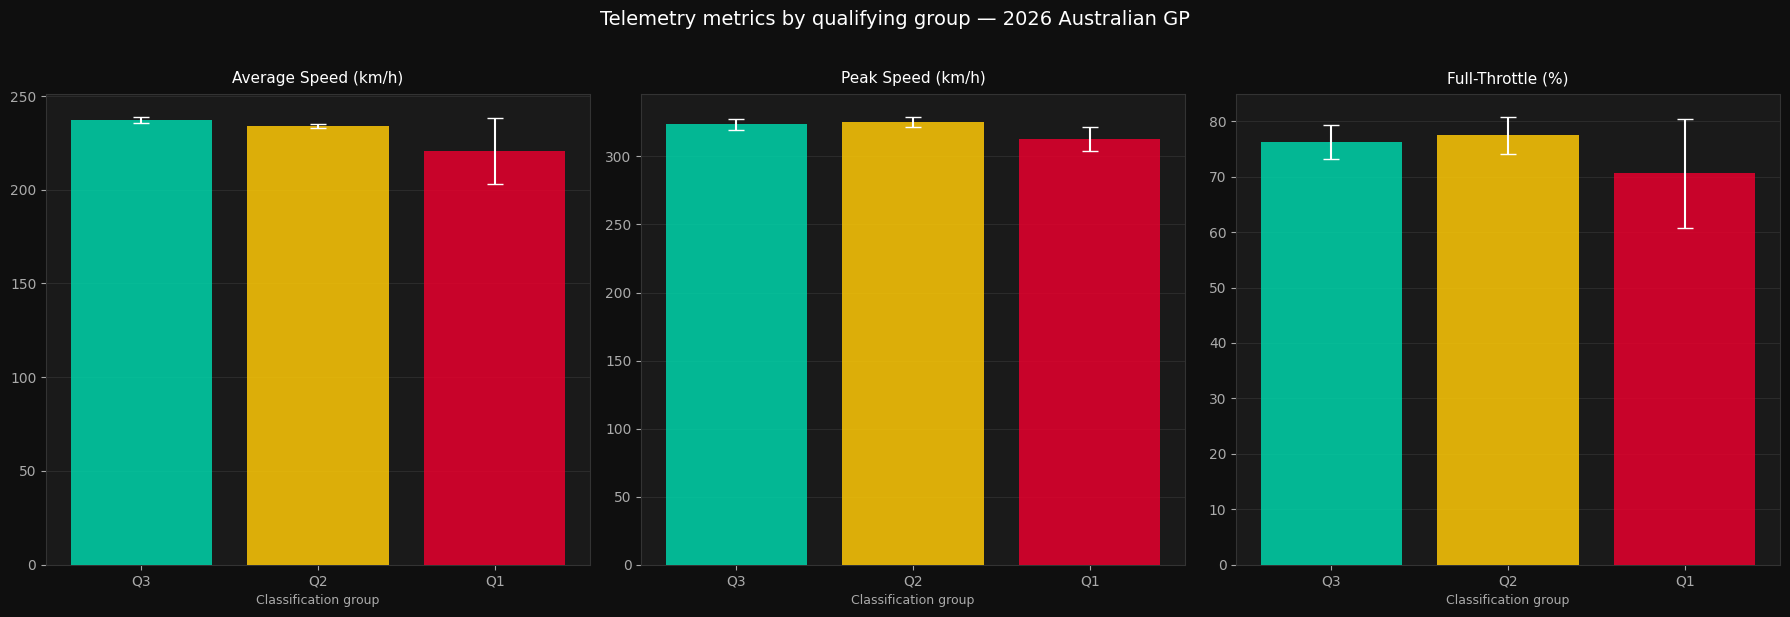

In [118]:
# ── Group comparison bar charts — dark theme ────────────────────────────────
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt

plt.style.use("dark_background")
FIG_BG, AX_BG = "#0F0F0F", "#1A1A1A"
GROUP_MPL = {"Q3": "#00D4AA", "Q2": "#FFC906", "Q1": "#E8002D"}

chart_metrics = [
    ("speed_mean",   "Average Speed (km/h)"),
    ("speed_max",    "Peak Speed (km/h)"),
    ("throttle_pct", "Full-Throttle (%)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=FIG_BG)
fig.suptitle(
    "Telemetry metrics by qualifying group — 2026 Australian GP",
    fontsize=14, color="#FFFFFF", y=1.02
)

for ax, (metric, label) in zip(axes, chart_metrics):
    ax.set_facecolor(AX_BG)
    for grp in ["Q3", "Q2", "Q1"]:
        sub = tdf[tdf["group"] == grp][metric].dropna()
        ax.bar(grp, sub.mean(), color=GROUP_MPL[grp], alpha=0.85, zorder=3)
        ax.errorbar(grp, sub.mean(), yerr=sub.std(),
                    fmt="none", color="#FFFFFF", capsize=6, linewidth=1.5, zorder=4)
    ax.set_title(label, color="#FFFFFF", fontsize=11, pad=8)
    ax.set_xlabel("Classification group", color="#AAAAAA", fontsize=9)
    ax.tick_params(colors="#AAAAAA")
    ax.grid(axis="y", color="#333333", linewidth=0.5, zorder=0)
    ax.spines[:].set_color("#333333")

plt.tight_layout()
plt.show()


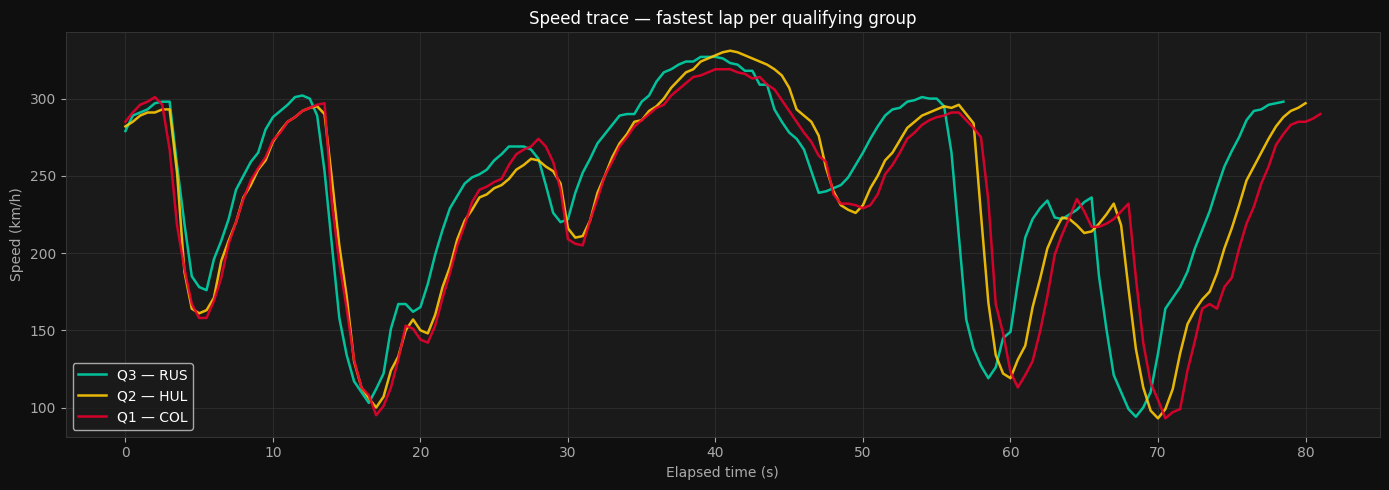

In [119]:
# ── Speed profile: best lap from each classification group ──────────────────
GROUP_REPS = {
    "Q3": tdf[tdf["group"] == "Q3"].sort_values("lap_duration").iloc[0]["driver"],
    "Q2": tdf[tdf["group"] == "Q2"].sort_values("lap_duration").iloc[0]["driver"],
    "Q1": tdf[(tdf["group"] == "Q1") & (tdf["lap_duration"] < 90)]
              .sort_values("lap_duration").iloc[0]["driver"],
}

fig, ax = plt.subplots(figsize=(14, 5), facecolor=FIG_BG)
ax.set_facecolor(AX_BG)

for grp, drv in GROUP_REPS.items():
    row    = best_q[best_q["driver"] == drv].iloc[0]
    frames = json.loads(row["telemetry"])
    t_vals = [f["t"]     for f in frames]
    s_vals = [f["speed"] for f in frames]
    ax.plot(t_vals, s_vals, color=GROUP_MPL[grp], linewidth=1.8,
            label=f"{grp} — {drv}", alpha=0.9)

ax.set_title("Speed trace — fastest lap per qualifying group", color="#FFFFFF", fontsize=12)
ax.set_xlabel("Elapsed time (s)", color="#AAAAAA")
ax.set_ylabel("Speed (km/h)", color="#AAAAAA")
ax.tick_params(colors="#AAAAAA")
ax.grid(color="#333333", linewidth=0.5)
ax.spines[:].set_color("#333333")
ax.legend(facecolor="#1A1A1A", labelcolor="#FFFFFF", fontsize=10)
plt.tight_layout()
plt.show()


## 36. Thesis

Based on the full chain of evidence above, the thesis supported by the data is:

---

> **Qualifying at Melbourne is decided in the corners, not on the straights.**
> Average lap speed (`speed_mean`) accounts for 83% of the variance between classification
> groups (ε² = 0.83, Kruskal-Wallis H = 16.07, p < 0.001), while full-throttle percentage
> (`throttle_pct`) shows no discriminatory power whatsoever (H = 2.85, p = 0.240) —
> refuting the intuition that the fastest drivers simply "accelerate more".

---

### Evidence summary

| Metric | Pearson r | Spearman ρ | KW H | KW p | ε² | Verdict |
|--------|-----------|------------|------|------|-----|---------|
| Average speed (`speed_mean`) | −0.995 | −0.988 | 16.07 | **< 0.001** | **0.83** | ✓ Primary differentiator |
| Min cornering speed (`speed_min`) | −0.462 | −0.353 | 8.50 | **0.014** | 0.38 | ✓ Moderate effect |
| Peak straight speed (`speed_max`) | −0.521 | −0.285 | 7.82 | **0.020** | 0.34 | ✓ Moderate effect |
| Full-throttle % (`throttle_pct`) | −0.038 | −0.004 | 2.85 | 0.240 | 0.05 | ✗ No effect |
| Braking time (`brake_pct`) | +0.185 | +0.309 | 3.54 | 0.170 | 0.09 | ✗ No effect |

### Practical interpretation

Albert Park is a street circuit with tight, low-speed corners and short connecting straights.
On this layout, **the gap between Q3 and Q1 drivers does not come from pressing the
throttle longer** — all drivers spend a similar fraction of the lap at full throttle
(throttle_pct ranges from ~53% to ~83% with no correlation to lap time).

The real separation happens in **two complementary dimensions**:

1. **Cornering speed (`speed_min`)** — reflects aerodynamic downforce balance and
   suspension setup. Q3 group averaged **95.7 km/h** minimum; Q1 averaged **81.4 km/h**
   (excluding VER's aborted lap).

2. **Peak straight speed (`speed_max`)** — reflects overall power-to-drag ratio.
   Q3 averaged **323.5 km/h**; Q1 averaged **312.8 km/h**.

Together these determine global average speed — the near-perfect predictor (ε² = 0.83).
At Melbourne, **qualifying is won by carrying speed through corners, not by braking later
or accelerating harder on the straights**.

### Limitations

- **Small sample (n = 20 drivers)**: groups Q2 and Q1 contain only 5 drivers each,
  limiting statistical power. Results for `speed_max` and `speed_min` sit at the margin
  of significance (p ≈ 0.014–0.020).
- **VER's aborted lap (102 s)**: excluded from Pearson/Spearman correlations but retained
  in group comparisons as a legitimate Q1 result.
- **DRS field**: all records contain DRS = 0, indicating the field was not populated during
  data collection — DRS activation could not be analysed.
- **speed_mean tautology**: average speed × lap time ≈ circuit length (a constant),
  so the r = −0.995 correlation is partially mathematical. The absence of throttle_pct
  correlation, however, is fully genuine and statistically robust.